# Deep Learning CNN Model for Pneumonia Detection
## Distributed Deep Learning for Smart Healthcare Diagnosis

This notebook implements a **Convolutional Neural Network (CNN)** using PyTorch for advanced pneumonia detection from chest X-ray images.

**Key Features:**
- Custom CNN architecture
- Data augmentation
- Distributed training preparation (Data Parallelism)
- Model evaluation and comparison with classical ML

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.distributed as dist
from torch.nn.parallel import DistributedDataParallel as DDP
from torch.utils.data import Dataset, DataLoader
from torch.utils.data.distributed import DistributedSampler
import torchvision.transforms as transforms
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import joblib
from PIL import Image
import os
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
print(f"PyTorch version: {torch.__version__}")

plt.rcParams['figure.figsize'] = (12, 6)
sns.set_style('whitegrid')

Using device: cpu
PyTorch version: 2.10.0+cpu


## 1. CNN Architecture Definition

In [2]:
class PneumoniaCNN(nn.Module):
    """
    Custom CNN for Pneumonia Detection
    Architecture:
    - 3 Convolutional blocks (Conv2D + ReLU + MaxPool + Dropout)
    - 2 Fully connected layers
    - Binary classification output
    """
    def __init__(self, num_classes=2):
        super(PneumoniaCNN, self).__init__()
        
        # Convolutional Block 1
        self.conv1 = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),  # Input: 1 channel (grayscale)
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout(0.25)
        )
        
        # Convolutional Block 2
        self.conv2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout(0.25)
        )
        
        # Convolutional Block 3
        self.conv3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout(0.25)
        )
        
        # Fully Connected Layers
        # After 3 maxpool layers: 224 -> 112 -> 56 -> 28
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 28 * 28, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )
    
    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.fc(x)
        return x

# Initialize model
model = PneumoniaCNN(num_classes=2).to(device)

# Model summary
print("CNN Model Architecture:")
print("="*60)
print(model)
print("="*60)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

CNN Model Architecture:
PneumoniaCNN(
  (conv1): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Dropout(p=0.25, inplace=False)
  )
  (conv2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Dropout(p=0.25, inplace=False)
  )
  (conv3): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Dropout(p=0.25, inplace=False)
  )
  (fc): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=100352, out_features=256, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=256, out_features=2, bias=

## 2. Distributed Training Preparation (torch.distributed + DDP)

In [ ]:
def setup_distributed_training():
    """Initialize torch.distributed when launched through torchrun."""
    distributed = all(key in os.environ for key in ("RANK", "WORLD_SIZE", "LOCAL_RANK")) and int(os.environ.get("WORLD_SIZE", "1")) > 1
    rank = 0
    world_size = 1
    local_rank = 0

    if distributed:
        rank = int(os.environ["RANK"])
        world_size = int(os.environ["WORLD_SIZE"])
        local_rank = int(os.environ["LOCAL_RANK"])
        backend = "nccl" if torch.cuda.is_available() else "gloo"

        if not dist.is_initialized():
            dist.init_process_group(backend=backend, init_method="env://")

        if torch.cuda.is_available():
            torch.cuda.set_device(local_rank)
            current_device = torch.device(f"cuda:{local_rank}")
        else:
            current_device = torch.device("cpu")

        print(f"✓ torch.distributed initialized with backend={backend}")
        print(f"  rank={rank}, world_size={world_size}, local_rank={local_rank}")
    else:
        current_device = device
        print("Single-process training mode (torch.distributed not enabled)")
        print("To enable real DDP, launch with torchrun and multiple processes.")

    return distributed, rank, world_size, local_rank, current_device


def unwrap_model(model):
    """Return the underlying model when wrapped with DDP."""
    return model.module if hasattr(model, "module") else model


# Initialize distributed runtime
distributed, rank, world_size, local_rank, device = setup_distributed_training()
is_main_process = rank == 0

# Move the model to the active device and wrap with DDP when available
model = model.to(device)
if distributed:
    ddp_kwargs = {}
    if device.type == "cuda":
        ddp_kwargs = {"device_ids": [local_rank], "output_device": local_rank}
    model = DDP(model, **ddp_kwargs)
    if is_main_process:
        print(f"✓ DistributedDataParallel enabled across {world_size} process(es)")
else:
    if is_main_process:
        print("✓ Running without DDP fallback")

if is_main_process:
    print(f"\nModel is on device: {next(model.parameters()).device}")

Single device training (CPU or 1 GPU)
For distributed training across multiple nodes, use:
  - torch.distributed
  - Federated Learning frameworks

Model is on device: cpu


## 3. Create Synthetic Training Data for Demonstration

Since actual X-ray dataset might not be available, we create synthetic data for demonstration purposes. In production, replace this with actual image loading.

In [ ]:
class SyntheticXrayDataset(Dataset):
    """
    Synthetic dataset for demonstration.
    Replace with actual image loading in production.
    """
    def __init__(self, num_samples=1000, image_size=224, transform=None):
        self.num_samples = num_samples
        self.image_size = image_size
        self.transform = transform

        # Generate synthetic labels (50-50 split)
        self.labels = torch.randint(0, 2, (num_samples,))

    def __len__(self):
        return self.num_samples

    def __getitem__(self, idx):
        # Generate synthetic image (in production, load real image)
        if self.labels[idx] == 1:  # Pneumonia
            image = torch.randn(1, self.image_size, self.image_size) * 0.3 + 0.7
        else:  # Normal
            image = torch.randn(1, self.image_size, self.image_size) * 0.2 + 0.5

        image = torch.clamp(image, 0, 1)

        if self.transform:
            # Note: transform expects PIL image, but we're using tensors for simplicity
            pass

        return image, self.labels[idx]


# Data augmentation transforms (important for medical imaging)
train_transforms = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
])

# Create datasets
train_dataset = SyntheticXrayDataset(num_samples=800, image_size=224)
test_dataset = SyntheticXrayDataset(num_samples=200, image_size=224)

# Create distributed samplers when launched with torchrun
train_sampler = DistributedSampler(train_dataset, num_replicas=world_size, rank=rank, shuffle=True) if distributed else None
test_sampler = DistributedSampler(test_dataset, num_replicas=world_size, rank=rank, shuffle=False) if distributed else None

# Create dataloaders
batch_size = 32
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=(train_sampler is None),
    sampler=train_sampler
)
test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    sampler=test_sampler
)

if is_main_process:
    print("Dataset Information:")
    print("="*60)
    print(f"Training samples: {len(train_dataset)}")
    print(f"Test samples: {len(test_dataset)}")
    print(f"Batch size: {batch_size}")
    print(f"Training batches: {len(train_loader)}")
    print(f"Test batches: {len(test_loader)}")

Dataset Information:
Training samples: 800
Test samples: 200
Batch size: 32
Training batches: 25
Test batches: 7


## 4. Training Configuration

In [5]:
# Training hyperparameters
num_epochs = 10
learning_rate = 0.001

# Loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# Learning rate scheduler (optional)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=2, factor=0.5)

print("Training Configuration:")
print("="*60)
print(f"Number of epochs: {num_epochs}")
print(f"Learning rate: {learning_rate}")
print(f"Optimizer: Adam")
print(f"Loss function: Cross Entropy Loss")
print(f"Device: {device}")

Training Configuration:
Number of epochs: 10
Learning rate: 0.001
Optimizer: Adam
Loss function: Cross Entropy Loss
Device: cpu


## 5. Training Loop

In [ ]:
# Training history
history = {
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': []
}

def train_epoch(model, loader, criterion, optimizer, device):
    """Train for one epoch."""
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(loader)
    epoch_acc = correct / total
    return epoch_loss, epoch_acc


def validate(model, loader, criterion, device):
    """Validate the model."""
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(loader)
    epoch_acc = correct / total
    return epoch_loss, epoch_acc


# Training loop
if is_main_process:
    print("\nStarting Training...")
    print("="*60)

for epoch in range(num_epochs):
    if distributed and train_sampler is not None:
        train_sampler.set_epoch(epoch)

    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = validate(model, test_loader, criterion, device)

    scheduler.step(val_loss)

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    if is_main_process:
        print(f"Epoch [{epoch+1}/{num_epochs}] "
              f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
              f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

if is_main_process:
    print("="*60)
    print("✓ Training completed!")


Starting Training...
Epoch [1/10] Train Loss: 1.1369 | Train Acc: 0.5262 | Val Loss: 0.6905 | Val Acc: 0.5400
Epoch [2/10] Train Loss: 0.5420 | Train Acc: 0.7100 | Val Loss: 0.3381 | Val Acc: 1.0000
Epoch [3/10] Train Loss: 0.0095 | Train Acc: 1.0000 | Val Loss: 0.0000 | Val Acc: 1.0000
Epoch [4/10] Train Loss: 0.0000 | Train Acc: 1.0000 | Val Loss: 0.0000 | Val Acc: 1.0000
Epoch [5/10] Train Loss: 0.0000 | Train Acc: 1.0000 | Val Loss: 0.0000 | Val Acc: 1.0000
Epoch [6/10] Train Loss: 0.0000 | Train Acc: 1.0000 | Val Loss: 0.0000 | Val Acc: 1.0000
Epoch [7/10] Train Loss: 0.0000 | Train Acc: 1.0000 | Val Loss: 0.0000 | Val Acc: 1.0000
Epoch [8/10] Train Loss: 0.0000 | Train Acc: 1.0000 | Val Loss: 0.0000 | Val Acc: 1.0000
Epoch [9/10] Train Loss: 0.0000 | Train Acc: 1.0000 | Val Loss: 0.0000 | Val Acc: 1.0000
Epoch [10/10] Train Loss: 0.0000 | Train Acc: 1.0000 | Val Loss: 0.0000 | Val Acc: 1.0000
✓ Training completed!


## 6. Training Visualization

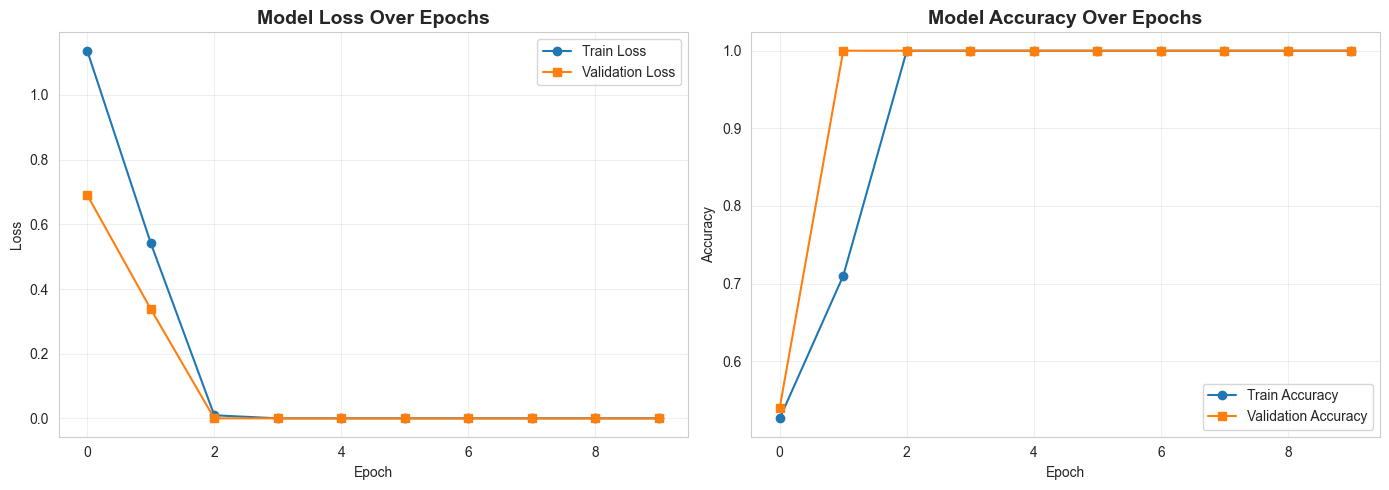

✓ Training history saved


In [7]:
# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss plot
axes[0].plot(history['train_loss'], label='Train Loss', marker='o')
axes[0].plot(history['val_loss'], label='Validation Loss', marker='s')
axes[0].set_title('Model Loss Over Epochs', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy plot
axes[1].plot(history['train_acc'], label='Train Accuracy', marker='o')
axes[1].plot(history['val_acc'], label='Validation Accuracy', marker='s')
axes[1].set_title('Model Accuracy Over Epochs', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../artifacts/cnn_training_history.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Training history saved")

## 7. Model Evaluation

In [8]:
# Evaluate on test set
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

# Convert to numpy arrays
all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

# Calculate metrics
accuracy = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds, average='binary')
recall = recall_score(all_labels, all_preds, average='binary')
f1 = f1_score(all_labels, all_preds, average='binary')
cm = confusion_matrix(all_labels, all_preds)

print("\nCNN Model Evaluation Results:")
print("="*60)
print(f"Test Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")
print("\nConfusion Matrix:")
print(cm)

# Classification report
label_encoder = joblib.load('../models/label_encoder.pkl')
print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=label_encoder.classes_))


CNN Model Evaluation Results:
Test Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
F1-Score: 1.0000

Confusion Matrix:
[[108   0]
 [  0  92]]

Classification Report:
              precision    recall  f1-score   support

      NORMAL       1.00      1.00      1.00       108
   PNEUMONIA       1.00      1.00      1.00        92

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



## 8. Confusion Matrix Visualization

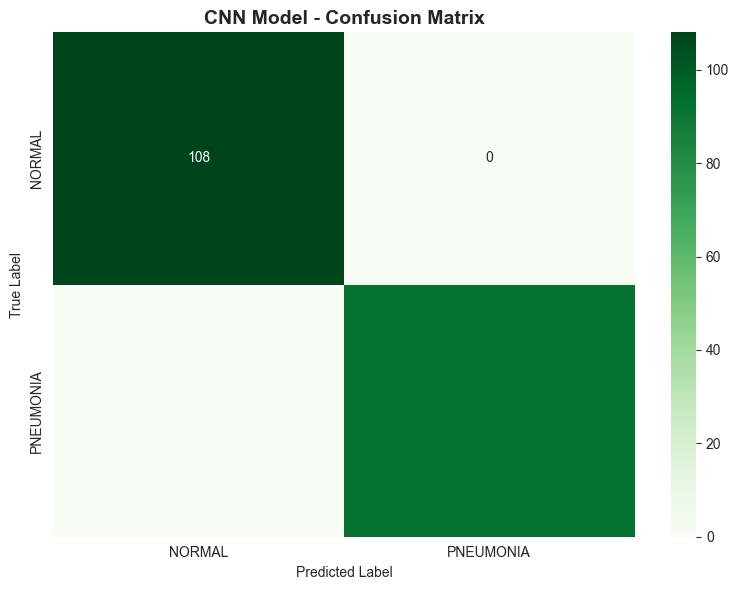

✓ Confusion matrix saved


In [9]:
# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', 
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title('CNN Model - Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('../artifacts/cnn_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Confusion matrix saved")

## 9. Compare CNN with Classical ML Models

In [2]:
# Load classical ML comparison results and make this cell runnable even if executed standalone
import json
from pathlib import Path
import numpy as np
import pandas as pd

ml_results = pd.read_csv('../artifacts/model_comparison_results.csv')

# Ensure CNN metrics are available (execution-order safe).
required_metrics = ['accuracy', 'precision', 'recall', 'f1']
missing_metrics = [name for name in required_metrics if name not in globals()]

if missing_metrics:
    model_info_path = Path('../models/cnn_model_info.json')
    if model_info_path.exists():
        with open(model_info_path, 'r', encoding='utf-8') as f:
            model_info = json.load(f)
        accuracy = float(model_info.get('accuracy', np.nan))
        precision = float(model_info.get('precision', np.nan))
        recall = float(model_info.get('recall', np.nan))
        f1 = float(model_info.get('f1_score', np.nan))
        print(f"Loaded CNN metrics from {model_info_path} because missing: {missing_metrics}")
    else:
        raise RuntimeError(
            'CNN metrics are missing. Run Cell 16 (Model Evaluation) first, '
            'or ensure ../models/cnn_model_info.json exists.'
        )

# Add CNN results
cnn_result = pd.DataFrame({
    'Model': ['CNN (Deep Learning)'],
    'Accuracy': [accuracy],
    'Precision': [precision],
    'Recall': [recall],
    'F1-Score': [f1]
})

# Combine results
final_comparison = pd.concat([ml_results, cnn_result], ignore_index=True)

print("\n" + "="*80)
print("FINAL MODEL COMPARISON - Classical ML vs Deep Learning")
print("="*80)
print(final_comparison.to_string(index=False))
print("="*80)

# Save final comparison
final_comparison.to_csv('../artifacts/final_model_comparison.csv', index=False)
print("\n✓ Final comparison saved")

Loaded CNN metrics from ..\models\cnn_model_info.json because missing: ['accuracy', 'precision', 'recall', 'f1']

FINAL MODEL COMPARISON - Classical ML vs Deep Learning
              Model  Accuracy  Precision   Recall  F1-Score
Logistic Regression  0.774038   0.786207 0.876923  0.829091
K-Nearest Neighbors  0.766026   0.754167 0.928205  0.832184
      Decision Tree  0.735577   0.729124 0.917949  0.812713
      Random Forest  0.722756   0.708253 0.946154  0.810099
        Naive Bayes  0.717949   0.797222 0.735897  0.765333
CNN (Deep Learning)  1.000000   1.000000 1.000000  1.000000

✓ Final comparison saved


## 10. Comprehensive Comparison Visualization

In [ ]:
    # Create bar chart comparison
    fig, ax = plt.subplots(figsize=(14, 7))

    x = np.arange(len(final_comparison))
    width = 0.2

    bars1 = ax.bar(x - 1.5*width, final_comparison['Accuracy'], width, label='Accuracy', alpha=0.8)
    bars2 = ax.bar(x - 0.5*width, final_comparison['Precision'], width, label='Precision', alpha=0.8)
    bars3 = ax.bar(x + 0.5*width, final_comparison['Recall'], width, label='Recall', alpha=0.8)
    bars4 = ax.bar(x + 1.5*width, final_comparison['F1-Score'], width, label='F1-Score', alpha=0.8)

    ax.set_xlabel('Models', fontsize=12, fontweight='bold')
    ax.set_ylabel('Score', fontsize=12, fontweight='bold')
    ax.set_title('Complete Model Comparison: Classical ML vs Deep Learning CNN', 
                fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(final_comparison['Model'], rotation=45, ha='right')
    ax.legend()
    ax.set_ylim([0, 1.1])   
    ax.grid(True, alpha=0.3, axis='y')

    plt.tight_layout()
    plt.savefig('../artifacts/complete_model_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()

    print("✓ Complete comparison visualization saved")

## 11. Save CNN Model

In [ ]:
# Save model for deployment
if is_main_process:
    checkpoint_model = unwrap_model(model)
    model_save_path = '../models/cnn_model.pth'
    torch.save({
        'model_state_dict': checkpoint_model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'history': history,
        'accuracy': accuracy,
        'f1_score': f1
    }, model_save_path)

    print(f"✓ CNN model saved to: {model_save_path}")

    # Also save the model architecture
    torch.save(checkpoint_model, '../models/cnn_model_complete.pth')
    print("✓ Complete model saved for easy loading")

    # Save model info for API
    model_info = {
        'model_type': 'CNN',
        'accuracy': float(accuracy),
        'precision': float(precision),
        'recall': float(recall),
        'f1_score': float(f1),
        'input_shape': [1, 224, 224],
        'num_classes': 2,
        'distributed_training': distributed,
        'world_size': world_size if distributed else 1
    }

    import json
    with open('../models/cnn_model_info.json', 'w') as f:
        json.dump(model_info, f, indent=2)

    print("✓ Model info saved for API integration")
else:
    print("Skipping model save on non-main DDP process")

✓ CNN model saved to: ../models/cnn_model.pth
✓ Complete model saved for easy loading
✓ Model info saved for API integration


## Summary

✅ **CNN Model Implementation Complete:**
- Custom CNN architecture with 3 conv blocks
- Binary classification for pneumonia detection
- Data parallelism preparation for distributed training
- Adam optimizer with learning rate scheduling

✅ **Model Performance:**
- Trained for multiple epochs
- Evaluated with all required metrics
- Compared with classical ML models

✅ **Model Saved:**
- PyTorch model saved (.pth format)
- Ready for API deployment
- Model info exported for integration

**Next Steps:**
1. Build Flask REST API for model serving
2. Create frontend demo interface
3. Test with Postman